# CAN Bus Security Log Analysis
## Visualizing Intrusion Detection Alerts from Suricata IDS

This notebook analyzes security alerts related to CAN (Controller Area Network) bus attacks detected by Suricata IDS.

### 1. Import Libraries and Load Data

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# Load EVE JSON data
eve_data = []
with open('../suricata_logs/eve.json', 'r') as f:
    for line in f:
        try:
            eve_data.append(json.loads(line.strip()))
        except:
            pass

# Convert to DataFrame
df_eve = pd.DataFrame(eve_data)

# Filter only alert events
df_alerts = df_eve[df_eve['event_type'] == 'alert'].copy()

# Extract alert details
df_alerts['signature'] = df_alerts['alert'].apply(lambda x: x.get('signature', '') if isinstance(x, dict) else '')
df_alerts['signature_id'] = df_alerts['alert'].apply(lambda x: x.get('signature_id', 0) if isinstance(x, dict) else 0)
df_alerts['severity'] = df_alerts['alert'].apply(lambda x: x.get('severity', 0) if isinstance(x, dict) else 0)

# Convert timestamp to datetime
df_alerts['timestamp'] = pd.to_datetime(df_alerts['timestamp'])

print(f"Total alerts loaded: {len(df_alerts)}")
print(f"\nData shape: {df_alerts.shape}")
df_alerts.head()

Total alerts loaded: 20

Data shape: (20, 19)


,timestamp,flow_id,pcap_cnt,event_type,src_ip,src_port,dest_ip,dest_port,proto,ip_v,pkt_src,alert,app_proto,direction,flow,stats,signature,signature_id,severity
0,2026-02-04 16:30:41.658602+05:30,2.954033e+14,205.0,alert,192.168.0.4,5204.0,192.168.0.10,6000.0,UDP,4.0,wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",failed,to_server,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",NaN,CAN DoS Suspicious - Zero Payload (Sensor Fail...,1000003,3
1,2026-02-04 16:30:41.657989+05:30,2.927678e+14,201.0,alert,192.168.0.4,5200.0,192.168.0.10,6000.0,UDP,4.0,wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",failed,to_server,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",NaN,CAN DoS Suspicious - Zero Payload (Sensor Fail...,1000003,3
2,2026-02-04 16:30:41.658914+05:30,2.967435e+14,207.0,alert,192.168.0.4,5206.0,192.168.0.10,6000.0,UDP,4.0,wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",failed,to_server,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",NaN,CAN DoS Suspicious - Zero Payload (Sensor Fail...,1000003,3
3,2026-02-04 16:30:41.658758+05:30,2.960706e+14,206.0,alert,192.168.0.4,5205.0,192.168.0.10,6000.0,UDP,4.0,wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",failed,to_server,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",NaN,CAN DoS Suspicious - Zero Payload (Sensor Fail...,1000003,3
4,2026-02-04 16:30:41.659070+05:30,2.974132e+14,208.0,alert,192.168.0.4,5207.0,192.168.0.10,6000.0,UDP,4.0,wire/pcap,"{'action': 'allowed', 'gid': 1, 'signature_id'...",failed,to_server,"{'pkts_toserver': 1, 'pkts_toclient': 0, 'byte...",NaN,CAN DoS Suspicious - Zero Payload (Sensor Fail...,1000003,3


### 2. Data Overview

In [3]:
# Basic statistics
print("=" * 60)
print("ALERT SUMMARY")
print("=" * 60)
print(f"\nTotal Alerts: {len(df_alerts)}")
print(f"Time Range: {df_alerts['timestamp'].min()} to {df_alerts['timestamp'].max()}")
print(f"Duration: {df_alerts['timestamp'].max() - df_alerts['timestamp'].min()}")
print(f"\nUnique Source IPs: {df_alerts['src_ip'].nunique()}")
print(f"Unique Destination IPs: {df_alerts['dest_ip'].nunique()}")
print(f"\nAlert Types:")
print(df_alerts['signature'].value_counts())

ALERT SUMMARY

Total Alerts: 20
Time Range: 2026-02-04 16:30:41.657989+05:30 to 2026-02-04 16:30:41.660915+05:30
Duration: 0 days 00:00:00.002926

Unique Source IPs: 2
Unique Destination IPs: 1

Alert Types:
signature
CAN DoS Suspicious - Zero Payload (Sensor Failure)     10
CAN Diagnostic Flood - FF Payload (Bootloader Risk)    10
Name: count, dtype: int64


### 3. Alert Type Distribution

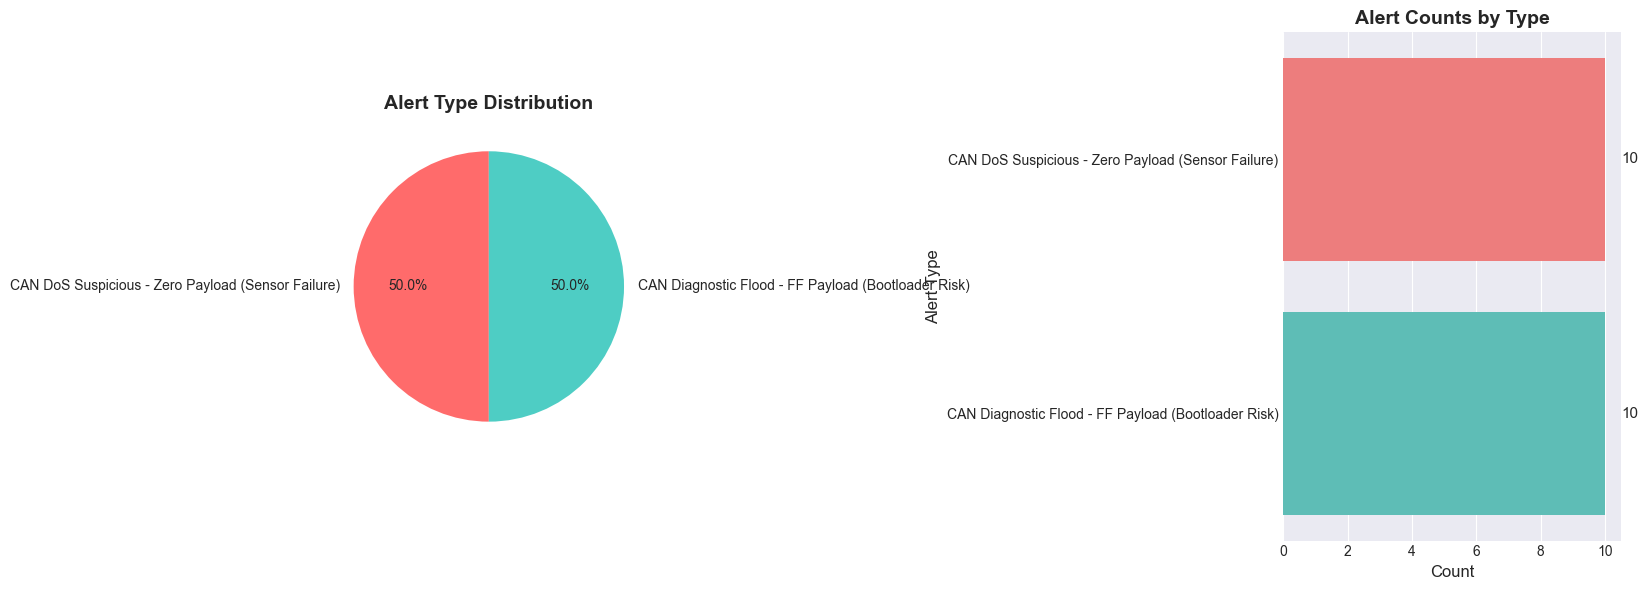

In [4]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
alert_counts = df_alerts['signature'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
axes[0].pie(alert_counts.values, labels=alert_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Alert Type Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.barplot(x=alert_counts.values, y=alert_counts.index, palette=colors, ax=axes[1])
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_ylabel('Alert Type', fontsize=12)
axes[1].set_title('Alert Counts by Type', fontsize=14, fontweight='bold')

# Add count labels on bars
for i, v in enumerate(alert_counts.values):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=11)

plt.tight_layout()
plt.show()

### 4. Attack Source Analysis

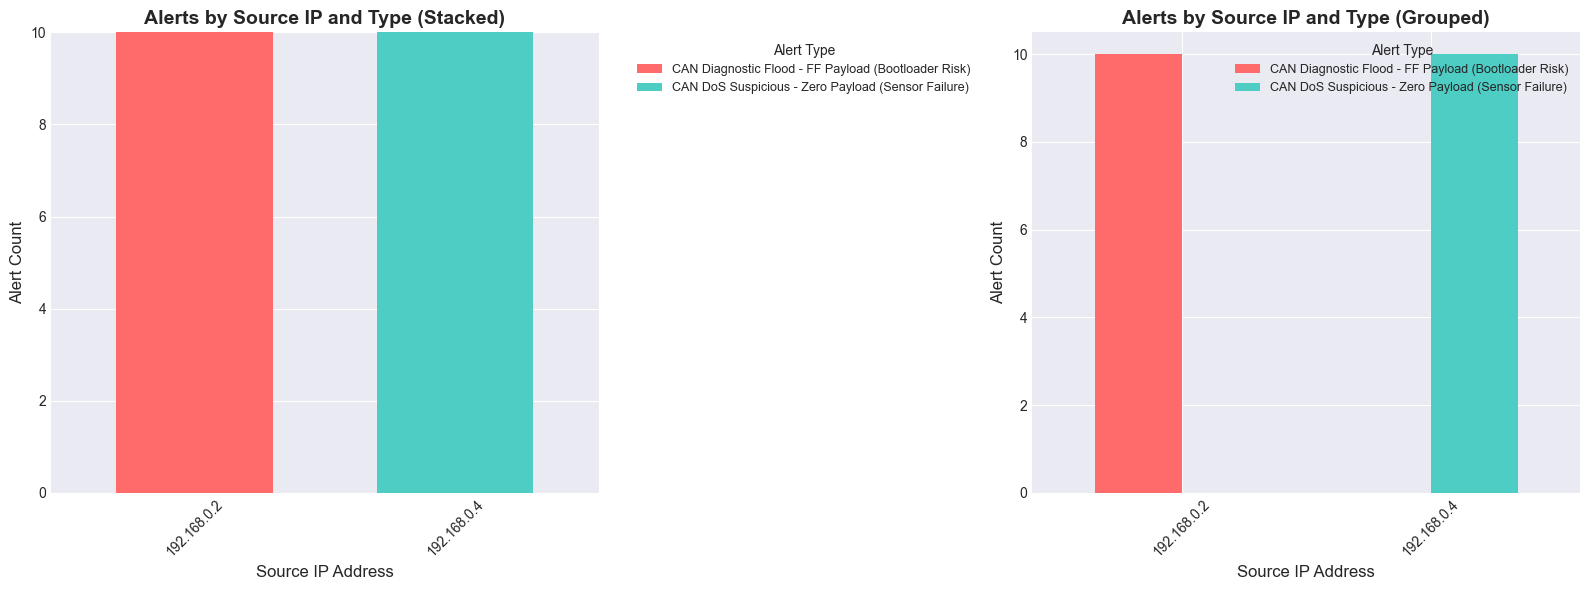


Source IP Summary:
     src_ip                                           signature  count
192.168.0.2 CAN Diagnostic Flood - FF Payload (Bootloader Risk)     10
192.168.0.4  CAN DoS Suspicious - Zero Payload (Sensor Failure)     10


In [5]:
# Group by source IP and alert type
source_analysis = df_alerts.groupby(['src_ip', 'signature']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
pivot_data = source_analysis.pivot(index='src_ip', columns='signature', values='count').fillna(0)
pivot_data.plot(kind='bar', stacked=True, ax=axes[0], color=['#FF6B6B', '#4ECDC4'], width=0.6)
axes[0].set_xlabel('Source IP Address', fontsize=12)
axes[0].set_ylabel('Alert Count', fontsize=12)
axes[0].set_title('Alerts by Source IP and Type (Stacked)', fontsize=14, fontweight='bold')
axes[0].legend(title='Alert Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[0].tick_params(axis='x', rotation=45)

# Grouped bar chart
pivot_data.plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#4ECDC4'], width=0.7)
axes[1].set_xlabel('Source IP Address', fontsize=12)
axes[1].set_ylabel('Alert Count', fontsize=12)
axes[1].set_title('Alerts by Source IP and Type (Grouped)', fontsize=14, fontweight='bold')
axes[1].legend(title='Alert Type', fontsize=9)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nSource IP Summary:")
print(source_analysis.to_string(index=False))

### 5. Timeline Analysis

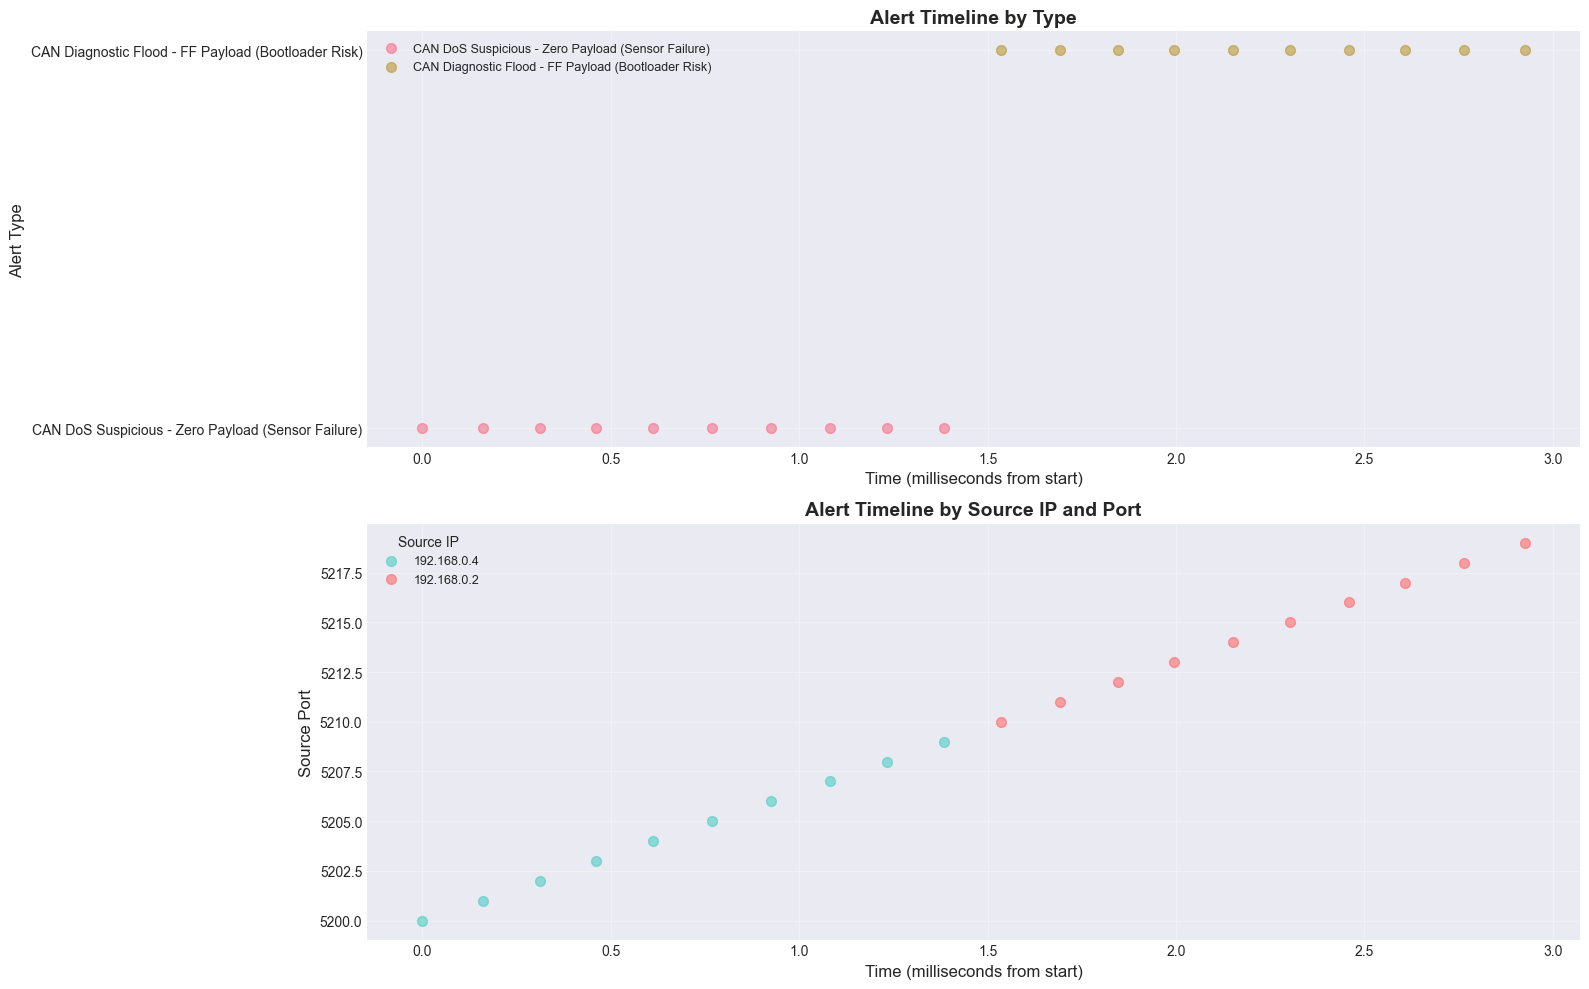

In [6]:
# Create timeline with microsecond resolution
df_alerts_sorted = df_alerts.sort_values('timestamp')

# Create elapsed time in milliseconds from first alert
df_alerts_sorted['elapsed_ms'] = (df_alerts_sorted['timestamp'] - df_alerts_sorted['timestamp'].min()).dt.total_seconds() * 1000

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Timeline by alert type
for sig in df_alerts_sorted['signature'].unique():
    data = df_alerts_sorted[df_alerts_sorted['signature'] == sig]
    axes[0].scatter(data['elapsed_ms'], [sig] * len(data), alpha=0.6, s=50, label=sig)

axes[0].set_xlabel('Time (milliseconds from start)', fontsize=12)
axes[0].set_ylabel('Alert Type', fontsize=12)
axes[0].set_title('Alert Timeline by Type', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Timeline by source IP
colors_ip = {'192.168.0.2': '#FF6B6B', '192.168.0.4': '#4ECDC4'}
for ip in df_alerts_sorted['src_ip'].unique():
    data = df_alerts_sorted[df_alerts_sorted['src_ip'] == ip]
    axes[1].scatter(data['elapsed_ms'], data['src_port'], 
                   alpha=0.6, s=50, label=ip, color=colors_ip.get(ip, 'gray'))

axes[1].set_xlabel('Time (milliseconds from start)', fontsize=12)
axes[1].set_ylabel('Source Port', fontsize=12)
axes[1].set_title('Alert Timeline by Source IP and Port', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Source IP', fontsize=9)

plt.tight_layout()
plt.show()

### 6. Port Analysis

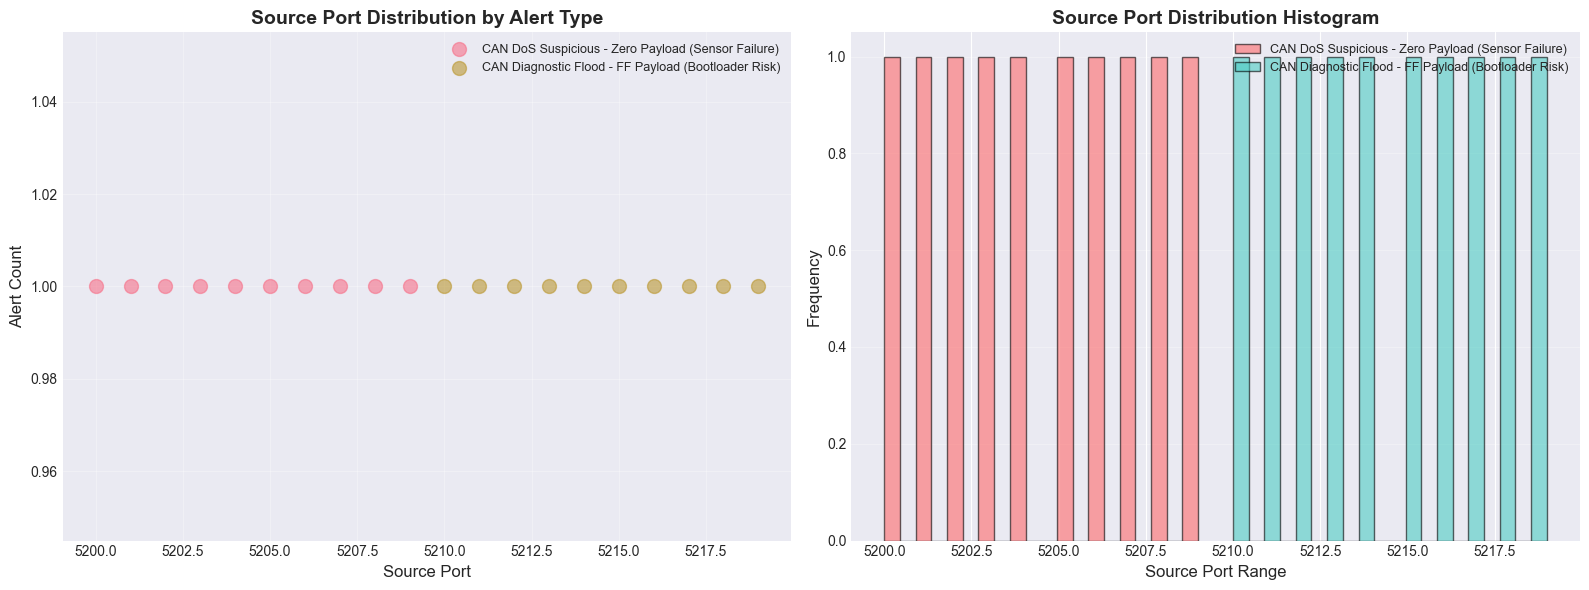


Port Range Summary:
Source ports range: 5200.0 - 5219.0
Destination port: [6000.]


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Source port distribution
port_signature = df_alerts.groupby(['src_port', 'signature']).size().reset_index(name='count')

# For each alert type, plot port distribution
for sig in df_alerts['signature'].unique():
    data = port_signature[port_signature['signature'] == sig]
    axes[0].scatter(data['src_port'], data['count'], alpha=0.6, s=100, label=sig)

axes[0].set_xlabel('Source Port', fontsize=12)
axes[0].set_ylabel('Alert Count', fontsize=12)
axes[0].set_title('Source Port Distribution by Alert Type', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Port range histogram
for sig, color in zip(df_alerts['signature'].unique(), ['#FF6B6B', '#4ECDC4']):
    data = df_alerts[df_alerts['signature'] == sig]['src_port']
    axes[1].hist(data, bins=20, alpha=0.6, label=sig, color=color, edgecolor='black')

axes[1].set_xlabel('Source Port Range', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Source Port Distribution Histogram', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nPort Range Summary:")
print(f"Source ports range: {df_alerts['src_port'].min()} - {df_alerts['src_port'].max()}")
print(f"Destination port: {df_alerts['dest_port'].unique()}")

### 7. Attack Pattern Heatmap

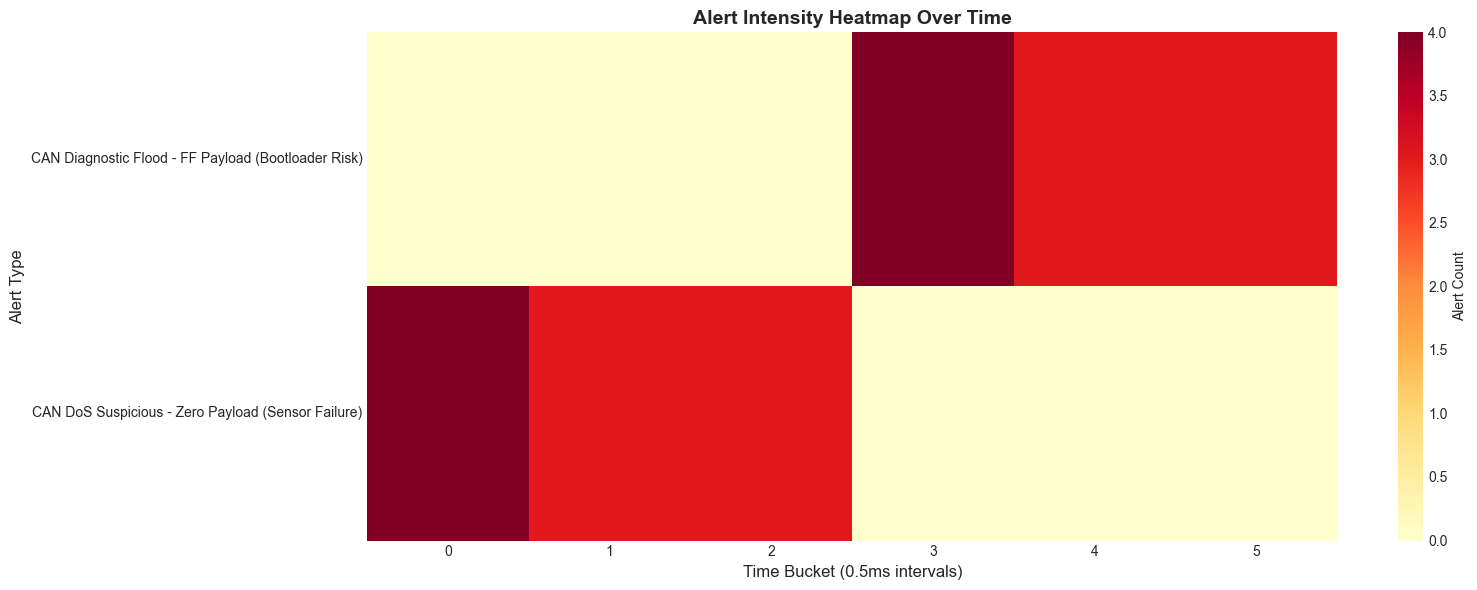

In [8]:
# Create a heatmap showing alert frequency over time
df_alerts_sorted['time_bucket'] = df_alerts_sorted['elapsed_ms'].apply(lambda x: int(x / 0.5))  # 0.5ms buckets

heatmap_data = df_alerts_sorted.groupby(['time_bucket', 'signature']).size().reset_index(name='count')
heatmap_pivot = heatmap_data.pivot(index='signature', columns='time_bucket', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_pivot, cmap='YlOrRd', annot=False, fmt='g', cbar_kws={'label': 'Alert Count'}, ax=ax)
ax.set_xlabel('Time Bucket (0.5ms intervals)', fontsize=12)
ax.set_ylabel('Alert Type', fontsize=12)
ax.set_title('Alert Intensity Heatmap Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8. Network Flow Visualization

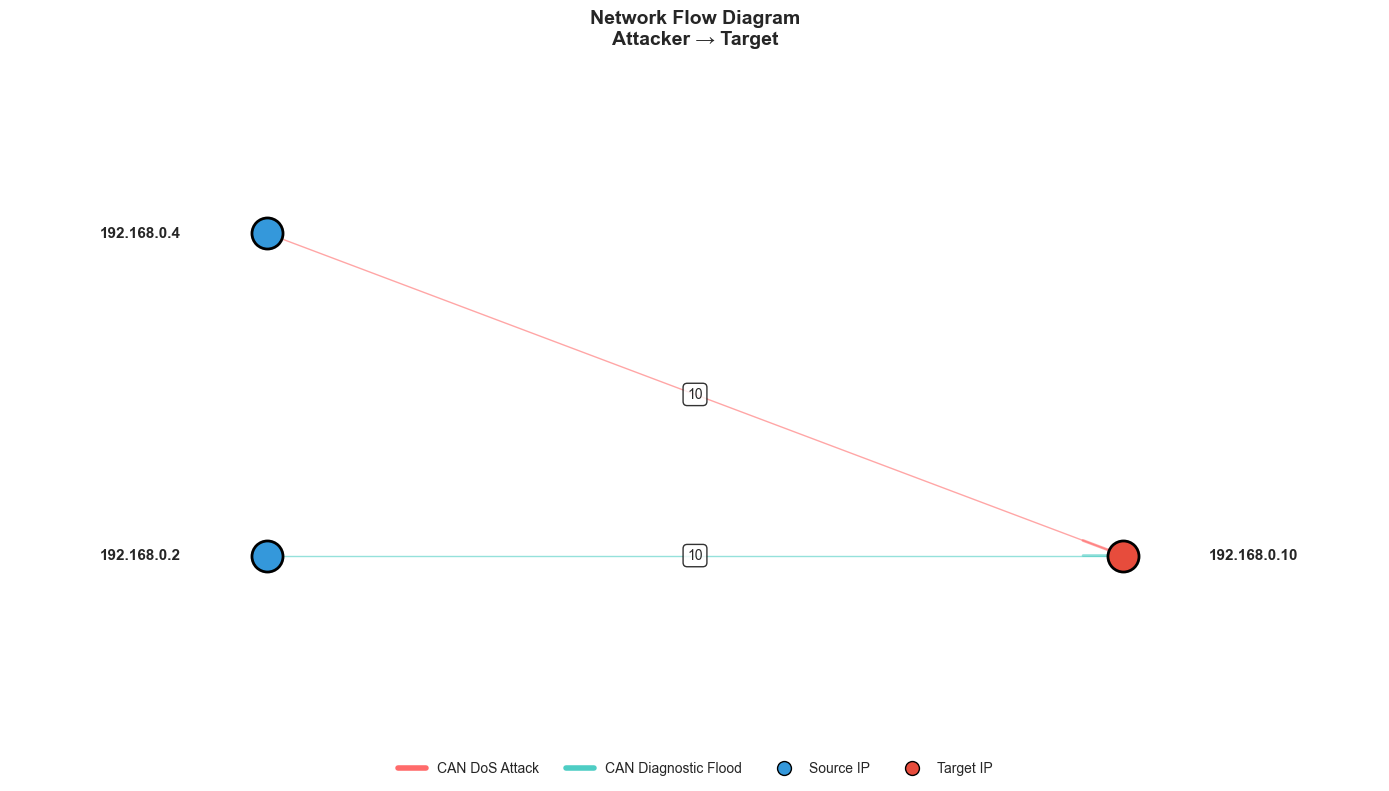

In [9]:
# Create a network flow diagram
flow_summary = df_alerts.groupby(['src_ip', 'dest_ip', 'signature']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 8))

# Define positions for source and destination IPs
src_ips = flow_summary['src_ip'].unique()
dest_ips = flow_summary['dest_ip'].unique()

src_y_positions = {ip: i for i, ip in enumerate(src_ips)}
dest_y_positions = {ip: i for i, ip in enumerate(dest_ips)}

# Plot connections
for _, row in flow_summary.iterrows():
    src_y = src_y_positions[row['src_ip']]
    dest_y = dest_y_positions[row['dest_ip']]
    
    color = '#FF6B6B' if 'DoS' in row['signature'] else '#4ECDC4'
    linewidth = row['count'] / 10
    
    ax.plot([0, 1], [src_y, dest_y], color=color, linewidth=linewidth, alpha=0.6)
    
    # Add arrow
    ax.annotate('', xy=(1, dest_y), xytext=(0.95, src_y + (dest_y - src_y) * 0.95),
                arrowprops=dict(arrowstyle='->', color=color, lw=2, alpha=0.6))
    
    # Add count label
    ax.text(0.5, (src_y + dest_y) / 2, str(row['count']), 
            ha='center', va='center', fontsize=10, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Plot source nodes
for ip, y in src_y_positions.items():
    ax.scatter(0, y, s=500, c='#3498db', zorder=10, edgecolor='black', linewidth=2)
    ax.text(-0.1, y, ip, ha='right', va='center', fontsize=11, fontweight='bold')

# Plot destination nodes
for ip, y in dest_y_positions.items():
    ax.scatter(1, y, s=500, c='#e74c3c', zorder=10, edgecolor='black', linewidth=2)
    ax.text(1.1, y, ip, ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.5, max(len(src_ips), len(dest_ips)) - 0.5)
ax.axis('off')
ax.set_title('Network Flow Diagram\nAttacker → Target', fontsize=14, fontweight='bold', pad=20)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#FF6B6B', lw=4, label='CAN DoS Attack'),
    Line2D([0], [0], color='#4ECDC4', lw=4, label='CAN Diagnostic Flood'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='Source IP', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Target IP', markeredgecolor='black')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=10)

plt.tight_layout()
plt.show()

### 9. Summary Statistics Table

In [10]:
# Create comprehensive summary table
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Alerts',
        'CAN DoS Alerts',
        'CAN Diagnostic Flood Alerts',
        'Unique Source IPs',
        'Unique Destination IPs',
        'Total Duration (ms)',
        'Average Alerts per ms',
        'Source Port Range'
    ],
    'Value': [
        len(df_alerts),
        len(df_alerts[df_alerts['signature'].str.contains('DoS')]),
        len(df_alerts[df_alerts['signature'].str.contains('Diagnostic')]),
        df_alerts['src_ip'].nunique(),
        df_alerts['dest_ip'].nunique(),
        f"{df_alerts_sorted['elapsed_ms'].max():.2f}",
        f"{len(df_alerts) / df_alerts_sorted['elapsed_ms'].max():.2f}" if df_alerts_sorted['elapsed_ms'].max() > 0 else 0,
        f"{df_alerts['src_port'].min()} - {df_alerts['src_port'].max()}"
    ]
})

print("\n" + "="*60)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*60)
print(summary_stats.to_string(index=False))
print("="*60)

# Detailed breakdown by source IP
print("\n" + "="*60)
print("ALERTS BY SOURCE IP")
print("="*60)
ip_breakdown = df_alerts.groupby(['src_ip', 'signature']).agg({
    'flow_id': 'count',
    'src_port': ['min', 'max']
}).reset_index()
ip_breakdown.columns = ['Source IP', 'Alert Type', 'Count', 'Min Port', 'Max Port']
print(ip_breakdown.to_string(index=False))
print("="*60)


COMPREHENSIVE SUMMARY STATISTICS
                     Metric           Value
               Total Alerts              20
             CAN DoS Alerts              10
CAN Diagnostic Flood Alerts              10
          Unique Source IPs               2
     Unique Destination IPs               1
        Total Duration (ms)            2.93
      Average Alerts per ms            6.84
          Source Port Range 5200.0 - 5219.0

ALERTS BY SOURCE IP
  Source IP                                          Alert Type  Count  Min Port  Max Port
192.168.0.2 CAN Diagnostic Flood - FF Payload (Bootloader Risk)     10    5210.0    5219.0
192.168.0.4  CAN DoS Suspicious - Zero Payload (Sensor Failure)     10    5200.0    5209.0


### 10. Export Analysis Report

In [11]:
# Export detailed analysis to CSV
output_file = 'can_security_analysis_report.csv'
df_alerts_sorted[['timestamp', 'src_ip', 'src_port', 'dest_ip', 'dest_port', 
                  'signature', 'severity', 'elapsed_ms']].to_csv(output_file, index=False)
print(f"\nDetailed analysis exported to: {output_file}")

# Save summary statistics
summary_file = 'can_security_summary.csv'
summary_stats.to_csv(summary_file, index=False)
print(f"Summary statistics exported to: {summary_file}")


Detailed analysis exported to: can_security_analysis_report.csv
Summary statistics exported to: can_security_summary.csv
